In [1]:
# 이진분류가 아닌 다중분류

from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
x, y = mnist['data'], mnist['target']

In [4]:
# SGD 분류모델을 이용하여 평가
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import pandas as pd

In [5]:
df = pd.DataFrame(x)
df['target'] = y
train_set, test_set = train_test_split(df, stratify=df['target'], train_size=0.5)
x_train = train_set.drop('target', axis=1).to_numpy()
y_train = train_set['target'].values

In [8]:
y_predicted = cross_val_predict(SGDClassifier(random_state=42), x_train, y_train, cv=3)
print(classification_report(y_train, y_predicted))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      3451
           1       0.95      0.96      0.95      3938
           2       0.91      0.83      0.87      3495
           3       0.79      0.87      0.83      3570
           4       0.90      0.87      0.89      3412
           5       0.72      0.86      0.78      3157
           6       0.91      0.94      0.93      3438
           7       0.94      0.87      0.90      3647
           8       0.83      0.69      0.75      3413
           9       0.81      0.85      0.83      3479

    accuracy                           0.87     35000
   macro avg       0.87      0.87      0.87     35000
weighted avg       0.87      0.87      0.87     35000



In [8]:
import seaborn as sns

df = sns.load_dataset('titanic')

x = df[['pclass', 'age', 'sex', 'sibsp', 'parch', 'embarked']] 
y = df['survived']


In [17]:
x

,pclass,age,sex,sibsp,parch,embarked
0,3,22.0,male,1,0,S
1,1,38.0,female,1,0,C
2,3,26.0,female,0,0,S
3,1,35.0,female,1,0,S
4,3,35.0,male,0,0,S
...,...,...,...,...,...,...
886,2,27.0,male,0,0,S
887,1,19.0,female,0,0,S
888,3,NaN,female,1,2,S
889,1,26.0,male,0,0,C


In [9]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

num_cols = ['age']
cat_ordinary_cols = ['pclass']
cat_onehot_cols = ['sex', 'sibsp','parch', 'embarked']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

x['pclass'] = x['pclass'].astype(str)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scale', OneHotEncoder())
])
preprocessing = ColumnTransformer([
    ('num_pipe', num_pipeline, num_cols),
    ('cat_pipe', cat_pipeline, cat_onehot_cols),
    ('cat_ord', OrdinalEncoder(categories=[['3','2','1']]), cat_ordinary_cols)
])

y_predicted = cross_val_predict(SGDClassifier(random_state=42), preprocessing.fit_transform(x), y, cv=3)
print(classification_report(y, y_predicted))

              precision    recall  f1-score   support

           0       0.78      0.90      0.83       549
           1       0.78      0.58      0.67       342

    accuracy                           0.78       891
   macro avg       0.78      0.74      0.75       891
weighted avg       0.78      0.78      0.77       891



C:\Users\Playdata\AppData\Local\Temp\ipykernel_1300\744654986.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['pclass'] = x['pclass'].astype(str)


In [10]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

num_cols = ['age']
cat_ordinary_cols = ['pclass']
cat_onehot_cols = ['sex', 'sibsp','parch', 'embarked']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

x['pclass'] = x['pclass'].astype(str)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scale', OneHotEncoder())
])
preprocessing = ColumnTransformer([
    ('num_pipe', num_pipeline, num_cols),
    ('cat_pipe', cat_pipeline, cat_onehot_cols),
    ('cat_ord', OrdinalEncoder(categories=[['3','2','1']]), cat_ordinary_cols)
])

y_predicted = cross_val_predict(SGDClassifier(class_weight={0:1, 1:2},random_state=42), preprocessing.fit_transform(x), y, cv=3)
print(classification_report(y, y_predicted))

              precision    recall  f1-score   support

           0       0.86      0.75      0.80       549
           1       0.67      0.81      0.73       342

    accuracy                           0.77       891
   macro avg       0.77      0.78      0.77       891
weighted avg       0.79      0.77      0.78       891



C:\Users\Playdata\AppData\Local\Temp\ipykernel_1300\722024977.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['pclass'] = x['pclass'].astype(str)


In [3]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import seaborn as sns

df = sns.load_dataset('titanic')

X = df.drop('alive', axis=1)
y = df['alive']

num_cols = ['age', 'sibsp', 'parch', 'fare']
cat_ordinary_cols = ['pclass']
cat_onehot_cols = ['sex', 'embarked']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

cat_ordinary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

cat_onehot_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat_ord', cat_ordinary_pipeline, cat_ordinary_cols),
    ('cat_oh', cat_onehot_pipeline, cat_onehot_cols)
])

# 🔥 모델까지 파이프라인으로 묶는 게 베스트
model = Pipeline([
    ('prep', preprocessing),
    ('clf', SGDClassifier(random_state=42))
])

y_pred = cross_val_predict(model, X, y, cv=3)

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

          no       0.81      0.80      0.80       549
         yes       0.68      0.69      0.69       342

    accuracy                           0.76       891
   macro avg       0.74      0.74      0.74       891
weighted avg       0.76      0.76      0.76       891



In [27]:
import seaborn as sns
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

df = sns.load_dataset('titanic')

X = df[['age','fare','sibsp','parch','pclass','sex','embarked']]
y = df['survived']   # 🔥 alive 말고 survived 추천 (숫자형)

num_cols = ['age','fare','sibsp','parch']
cat_cols = ['pclass','sex','embarked']

# 숫자 처리
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 범주 처리
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder())
])

# 합치기
preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# 모델 포함 파이프라인
model = Pipeline([
    ('prep', preprocessing),
    ('clf', LogisticRegression(max_iter=1000))
])

# 교차검증
y_pred = cross_val_predict(model, X, y, cv=5)

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       549
           1       0.74      0.69      0.72       342

    accuracy                           0.79       891
   macro avg       0.78      0.77      0.78       891
weighted avg       0.79      0.79      0.79       891



In [11]:
# 평가결과 시각화

from sklearn.metrics import roc_auc_score, roc_curve

fpr, tpr, threshold = roc_curve(y, y_predicted)
auc = roc_auc_score(y, y_predicted)

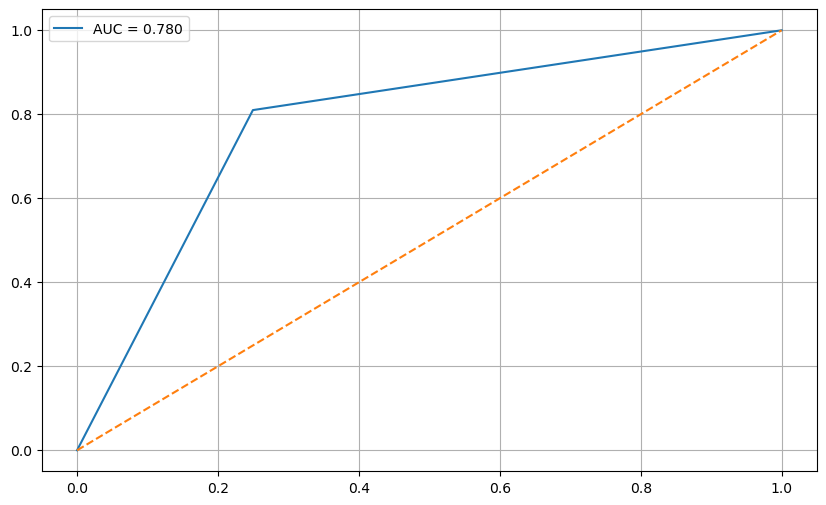

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
ax.plot([0,1],[0,1], linestyle='--')  #랜덤 기준선
plt.legend()
plt.grid()
plt.show()

In [25]:
import seaborn as sns

iris = sns.load_dataset('iris')

# 품종분류 모델 개발하고 성능 측정
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris.info()
# 결측치 없음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [27]:
# 정답과 분석 칼럼 분리
x = iris[['petal_length', 'petal_width']]
y = iris['species']

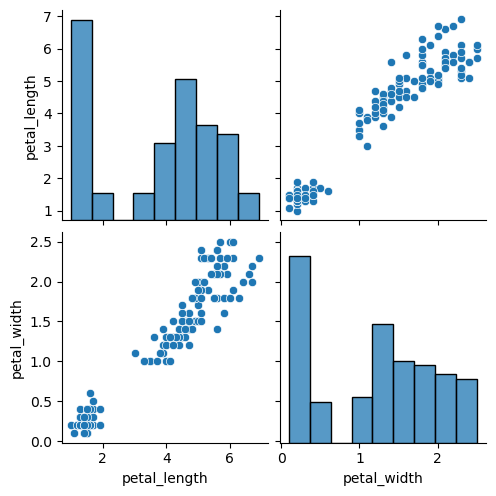

In [ ]:
# 분포도 확인
sns.pairplot(x)

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

model = Pipeline([
    ('clf', RandomForestClassifier(random_state=42))
])

y_pred = cross_val_predict(model, x, y, cv=5)

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.96      0.94      0.95        50
   virginica       0.94      0.96      0.95        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



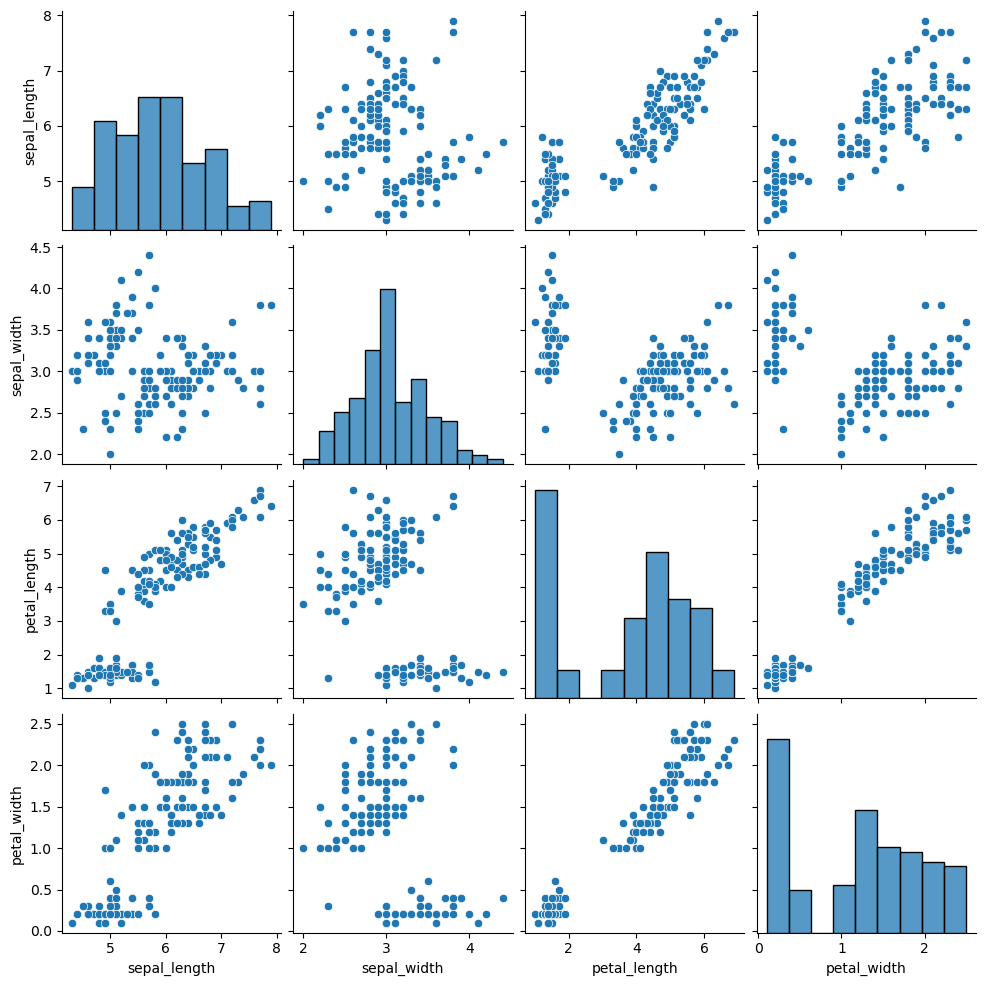

In [45]:
import seaborn as sns

iris = sns.load_dataset('iris')

# 품종분류 모델 개발하고 성능 측정
iris.head()

# 정답과 분석 칼럼 분리
x = iris.drop('species', axis=1)
y = iris['species']

# 분포도 확인
sns.pairplot(x)

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

model = Pipeline([
    ('clf', RandomForestClassifier(random_state=42))
])

y_pred = cross_val_predict(model, x, y, cv=5)

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.96      0.94      0.95        50
   virginica       0.94      0.96      0.95        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150

